# Single input single objective

### this notebook is made to plot an example of Bayesian optimization using one input and one objective. 

Our current test device is however not able to handle one input at the time, so we made a test optimization with 2 inputs, the second one being fixed at `x2=4`

## add the main repository to the path

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))

## imports

In [2]:
# library
import matplotlib.pyplot as plt
import torch

# project
from post_analysis.postAnalysis import PostAnalysis
from tests.test_function.target_function import target_function

## load the file

In [3]:
folder = "data/model_observations/"
file = "model_observations_000001.pt"

pa = PostAnalysis(path=folder + file)


            Date: 2026-06-04 16:33:31
            Observations: 23
            Inputs: 2
            Objectives: 1
            Initial observations: 4
            Repeats: 1
            Steps: 20
            


## get the initialization context

In [4]:
ctx_init = pa.get_context_at_step(step=1)

Context created.
Observation added: x=[3.7012863159179688, 4.0], y=[0.5470435619354248], shot_number=2
Observation added: x=[4.945160388946533, 4.0], y=[0.7210854887962341], shot_number=3
Observation added: x=[9.408039093017578, 4.0], y=[0.25326159596443176], shot_number=4
Observation added: x=[-0.5545055866241455, 4.0], y=[0.06985199451446533], shot_number=5


In [5]:
ctx_init.X_physical.shape   # we can verify that the the data as the same shape than the "Initial observations" from the metadata

torch.Size([4, 2])

## get the optimization steps

In [6]:
ctx_obs = pa.get_context_at_step(step=None)  # None means all steps

Context created.
Observation added: x=[3.7012863159179688, 4.0], y=[0.5470435619354248], shot_number=2
Observation added: x=[4.945160388946533, 4.0], y=[0.7210854887962341], shot_number=3
Observation added: x=[9.408039093017578, 4.0], y=[0.25326159596443176], shot_number=4
Observation added: x=[-0.5545055866241455, 4.0], y=[0.06985199451446533], shot_number=5
Observation added: x=[5.958216667175293, 4.0], y=[0.797712504863739], shot_number=7
Observation added: x=[6.335119247436523, 4.0], y=[0.7876061797142029], shot_number=9
Observation added: x=[5.7788310050964355, 4.0], y=[0.7948444485664368], shot_number=11
Observation added: x=[6.120423316955566, 4.0], y=[0.7960345149040222], shot_number=13
Observation added: x=[6.2126312255859375, 4.0], y=[0.7932742834091187], shot_number=15
Observation added: x=[6.0358734130859375, 4.0], y=[0.797416090965271], shot_number=17
Observation added: x=[5.910665512084961, 4.0], y=[0.7974342107772827], shot_number=19
Observation added: x=[5.9955205917358

In [8]:
ctx_obs.X_obs.shape  # we have 19 steps of optimization and one step of initialization

torch.Size([19, 2])

## Target function

since we are making a test, we can plot the theory

In [9]:
bounds = ctx_obs.bounds

x1 = torch.linspace(bounds[0, 0], bounds[1, 0], 1000)
x2 = torch.linspace(bounds[0, 1], bounds[1, 1], 1)

X1, X2 = torch.meshgrid(x1, x2, indexing="ij")

obj = target_function(X1, X2)
obj1 = obj[:, :, 0]
obj2 = obj[:, :, 1]

## plots

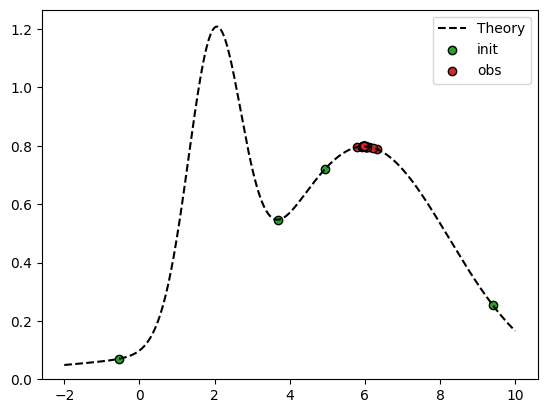

In [15]:
fig, ax1 = plt.subplots(1, 1)

# theory
ax1.plot(x1, obj1, label="Theory", color="k", ls="--")
ax1.set_ylim(0)

# init
ax1.scatter(ctx_init.X_physical[:, 0], ctx_init.Y_physical, label="init", color="tab:green", edgecolor="black")
ax1.legend()

# obs
ax1.scatter(ctx_obs.X_obs[:, 0], ctx_obs.Y_obs, label="obs", color="tab:red", edgecolor="black")
ax1.legend()